In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
train_dir = r"D:\AiMl\dataset\raw\train"
val_dir   = r"D:\AiMl\dataset\raw\val"
test_dir  = r"D:\AiMl\dataset\raw\test"

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: D:\AiMl\dataset\raw\train
Validation: D:\AiMl\dataset\raw\val
Test: D:\AiMl\dataset\raw\test


In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

NUM_CLASSES = 10

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)

Image size: (150, 150)
Batch size: 32
Classes: 10


In [5]:
train_generator = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

class_names = train_generator.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)

Found 2400 files belonging to 10 classes.
Classes:
0 -> Battery
1 -> Keyboard
2 -> Microwave
3 -> Mobile
4 -> Mouse
5 -> PCB
6 -> Player
7 -> Printer
8 -> Television
9 -> Washing Machine


In [6]:
val_generator = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("Validation dataset loaded")

Found 300 files belonging to 10 classes.
Validation dataset loaded


In [7]:
test_generator = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("Test dataset loaded")

Found 300 files belonging to 10 classes.
Test dataset loaded


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_generator = train_generator.prefetch(AUTOTUNE)
val_generator = val_generator.prefetch(AUTOTUNE)
test_generator = test_generator.prefetch(AUTOTUNE)

print("Data pipeline ready")

Data pipeline ready


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

print("Data augmentation ready")

Data augmentation ready


In [10]:
model = models.Sequential([

    # Input
    layers.Input(shape=(150, 150, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Classification
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,066 (3.99 MB)

 Trainable params: 1,045,066 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks ready")

Callbacks ready


In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30


d:\AiMl\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 453ms/step - accuracy: 0.1571 - loss: 2.2359 - val_accuracy: 0.3300 - val_loss: 2.0065 - learning_rate: 0.0010
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 479ms/step - accuracy: 0.3000 - loss: 1.9717 - val_accuracy: 0.3867 - val_loss: 1.7276 - learning_rate: 0.0010
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 439ms/step - accuracy: 0.3533 - loss: 1.8406 - val_accuracy: 0.4567 - val_loss: 1.5961 - learning_rate: 0.0010
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 413ms/step - accuracy: 0.3708 - loss: 1.7633 - val_accuracy: 0.4800 - val_loss: 1.4737 - learning_rate: 0.0010
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 444ms/step - accuracy: 0.4204 - loss: 1.6639 - val_accuracy: 0.5467 - val_loss: 1.3138 - learning_rate: 0.0010
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 452ms/step - accuracy: 0.4554 - loss: 1.5570 - val_accuracy: 0.4567 - val_loss: 1.4136 - learning_rate: 0.0010
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 424ms/step - accuracy: 0.4888 - loss: 1.5023 - val_

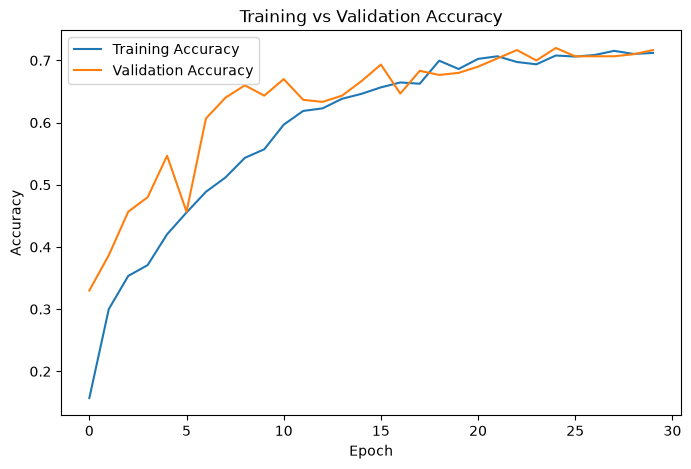

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

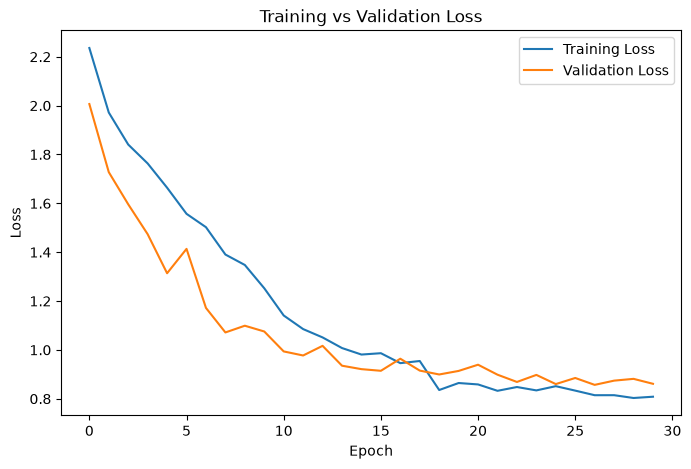

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("================================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("================================")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.6400 - loss: 0.9971
Test Loss: 0.9971
Test Accuracy: 64.00%


In [17]:
model_path = r"D:\AiMl\models\trained\ewaste_classifier.keras"

model.save(model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
D:\AiMl\models\trained\ewaste_classifier.keras


In [18]:
class_names_path = r"D:\AiMl\models\trained\class_names.txt"

with open(class_names_path, "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("Class names saved successfully:")
print(class_names_path)

Class names saved successfully:
D:\AiMl\models\trained\class_names.txt


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)

IMG_SIZE = (150, 150)
NUM_CLASSES = 10

TensorFlow: 2.21.0


In [2]:
base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

# Pehle pretrained layers ko freeze karenge
base_model.trainable = False

model_tl = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_tl.summary()

D:\pip-temp\ipykernel_16064\1328319631.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 83s 9us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Transfer learning model compiled successfully")

Transfer learning model compiled successfully


In [4]:
early_stopping_tl = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Transfer learning callbacks ready")

Transfer learning callbacks ready


In [6]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stopping_tl,
        reduce_lr_tl
    ]
)

NameError: name 'train_generator' is not defined

In [8]:
import tensorflow as tf

train_dir = r"D:\AiMl\dataset\raw\train"
val_dir = r"D:\AiMl\dataset\raw\val"
test_dir = r"D:\AiMl\dataset\raw\test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

# =========================
# TRAIN DATASET
# =========================
train_generator = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

# IMPORTANT: class names BEFORE prefetch
class_names = train_generator.class_names

# =========================
# VALIDATION DATASET
# =========================
val_generator = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# =========================
# TEST DATASET
# =========================
test_generator = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("Classes:", class_names)

# =========================
# PREFETCH
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_generator = train_generator.prefetch(AUTOTUNE)
val_generator = val_generator.prefetch(AUTOTUNE)
test_generator = test_generator.prefetch(AUTOTUNE)

print("Datasets ready")

Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Datasets ready


In [9]:
history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stopping_tl,
        reduce_lr_tl
    ]
)

Epoch 1/25


d:\AiMl\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


75/75 ━━━━━━━━━━━━━━━━━━━━ 38s 366ms/step - accuracy: 0.1804 - loss: 2.4521 - val_accuracy: 0.3133 - val_loss: 1.9341 - learning_rate: 1.0000e-04
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.3308 - loss: 1.9018 - val_accuracy: 0.4400 - val_loss: 1.6809 - learning_rate: 1.0000e-04
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.4187 - loss: 1.6782 - val_accuracy: 0.5100 - val_loss: 1.4903 - learning_rate: 1.0000e-04
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 270ms/step - accuracy: 0.4679 - loss: 1.5238 - val_accuracy: 0.5433 - val_loss: 1.3668 - learning_rate: 1.0000e-04
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - accuracy: 0.5213 - loss: 1.4140 - val_accuracy: 0.5600 - val_loss: 1.2815 - learning_rate: 1.0000e-04
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - accuracy: 0.5612 - loss: 1.3410 - val_accuracy: 0.5767 - val_loss: 1.2256 - learning_rate: 1.0000e-04
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.57

In [10]:
test_loss_tl, test_accuracy_tl = model_tl.evaluate(
    test_generator,
    verbose=1
)

print("\n====================================")
print("     MOBILENETV2 TEST RESULTS")
print("====================================")
print(f"Test Loss: {test_loss_tl:.4f}")
print(f"Test Accuracy: {test_accuracy_tl * 100:.2f}%")
print("====================================")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 249ms/step - accuracy: 0.6700 - loss: 0.9767

     MOBILENETV2 TEST RESULTS
Test Loss: 0.9767
Test Accuracy: 67.00%


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = (150, 150)
NUM_CLASSES = 10

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [12]:
base_model_correct = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

base_model_correct.trainable = False

model_tl_correct = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # MobileNetV2 preprocessing
    layers.Rescaling(1./127.5, offset=-1),

    base_model_correct,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_tl_correct.summary()

D:\pip-temp\ipykernel_16064\1317890898.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_correct = MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
model_tl_correct.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Correct MobileNetV2 model compiled successfully")

Correct MobileNetV2 model compiled successfully


In [14]:
early_stopping_correct = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_correct = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Callbacks ready")

Callbacks ready


In [1]:
history_correct = model_tl_correct.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stopping_correct,
        reduce_lr_correct
    ]
)

NameError: name 'model_tl_correct' is not defined

In [ ]:
test_loss_correct, test_accuracy_correct = model_tl_correct.evaluate(
    test_generator,
    verbose=1
)

print("\n====================================")
print("  CORRECT MOBILENETV2 TEST RESULTS")
print("====================================")
print(f"Test Loss: {test_loss_correct:.4f}")
print(f"Test Accuracy: {test_accuracy_correct * 100:.2f}%")
print("====================================")

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# =====================================================
# 1. DATASET PATHS
# =====================================================

train_dir = r"D:\AiMl\dataset\raw\train"
val_dir   = r"D:\AiMl\dataset\raw\val"
test_dir  = r"D:\AiMl\dataset\raw\test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

# =====================================================
# 2. LOAD DATASETS
# =====================================================

train_generator = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

class_names = train_generator.class_names

val_generator = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_generator = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("\nClasses:")
print(class_names)

# =====================================================
# 3. PREFETCH
# =====================================================

AUTOTUNE = tf.data.AUTOTUNE

train_generator = train_generator.prefetch(AUTOTUNE)
val_generator = val_generator.prefetch(AUTOTUNE)
test_generator = test_generator.prefetch(AUTOTUNE)

print("\nDatasets ready!")

# =====================================================
# 4. MOBILENETV2
# =====================================================

base_model_correct = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

base_model_correct.trainable = False

# =====================================================
# 5. BUILD MODEL
# =====================================================

model_tl_correct = models.Sequential([
    
    layers.Input(shape=(150, 150, 3)),

    # MobileNetV2 preprocessing
    layers.Rescaling(1./127.5, offset=-1),

    base_model_correct,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.4),

    layers.Dense(10, activation="softmax")
])

# =====================================================
# 6. COMPILE
# =====================================================

model_tl_correct.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =====================================================
# 7. CALLBACKS
# =====================================================

early_stopping_correct = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_correct = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# =====================================================
# 8. TRAIN MODEL
# =====================================================

print("\n====================================")
print("Starting MobileNetV2 Training")
print("====================================\n")

history_correct = model_tl_correct.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[
        early_stopping_correct,
        reduce_lr_correct
    ]
)

# =====================================================
# 9. TEST MODEL
# =====================================================

test_loss_correct, test_accuracy_correct = model_tl_correct.evaluate(
    test_generator,
    verbose=1
)

print("\n====================================")
print(" CORRECT MOBILENETV2 TEST RESULTS")
print("====================================")
print(f"Test Loss: {test_loss_correct:.4f}")
print(f"Test Accuracy: {test_accuracy_correct * 100:.2f}%")
print("====================================")

Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.

Classes:
['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']

Datasets ready!


D:\pip-temp\ipykernel_14368\2519145657.py:68: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_correct = MobileNetV2(



Starting MobileNetV2 Training

Epoch 1/25


d:\AiMl\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 272ms/step - accuracy: 0.3558 - loss: 1.9538 - val_accuracy: 0.7333 - val_loss: 1.0566 - learning_rate: 1.0000e-04
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.6879 - loss: 0.9753 - val_accuracy: 0.8667 - val_loss: 0.5737 - learning_rate: 1.0000e-04
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 221ms/step - accuracy: 0.7946 - loss: 0.6577 - val_accuracy: 0.9100 - val_loss: 0.3972 - learning_rate: 1.0000e-04
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 226ms/step - accuracy: 0.8558 - loss: 0.4854 - val_accuracy: 0.9200 - val_loss: 0.3233 - learning_rate: 1.0000e-04
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.8863 - loss: 0.3949 - val_accuracy: 0.9167 - val_loss: 0.2751 - learning_rate: 1.0000e-04
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.8996 - loss: 0.3430 - val_accuracy: 0.9233 - val_loss: 0.2466 - learning_rate: 1.0000e-04
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.91

In [4]:
from pathlib import Path

MODEL_DIR = Path(r"D:\AiMl\models\trained")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_DIR / "ewaste_mobilenetv2.keras"
CLASS_NAMES_PATH = MODEL_DIR / "class_names.txt"

# Save model
model_tl_correct.save(FINAL_MODEL_PATH)

# Save class names
with open(CLASS_NAMES_PATH, "w") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("====================================")
print("FINAL MODEL SAVED")
print("====================================")
print("Model:", FINAL_MODEL_PATH)
print("Classes:", CLASS_NAMES_PATH)
print("Test Accuracy: 94.33%")

FINAL MODEL SAVED
Model: D:\AiMl\models\trained\ewaste_mobilenetv2.keras
Classes: D:\AiMl\models\trained\class_names.txt
Test Accuracy: 94.33%
